device: cuda
0 {'loss': 3.2965497970581055, 'current': 0.0017071223119273782, 'divB': 0.0007184972055256367, 'bottom_bz': 0.32902365922927856, 'top_h': 0.03887692838907242}
500 {'loss': 0.014931763522326946, 'current': 0.007043119519948959, 'divB': 0.0032755229622125626, 'bottom_bz': 0.0004590403405018151, 'top_h': 0.00022717536194249988}
1000 {'loss': 0.004525481257587671, 'current': 0.002075299620628357, 'divB': 0.0017287920927628875, 'bottom_bz': 7.094735337886959e-05, 'top_h': 0.00011915607319679111}
1500 {'loss': 0.0021280546206980944, 'current': 0.001008240389637649, 'divB': 0.0008532045176252723, 'bottom_bz': 2.6090074243256822e-05, 'top_h': 5.7089997426373884e-05}
2000 {'loss': 0.0012481661979109049, 'current': 0.0005860135424882174, 'divB': 0.0004960906808264554, 'bottom_bz': 1.6109923308249563e-05, 'top_h': 4.962836828781292e-05}
2500 {'loss': 0.0008752938010729849, 'current': 0.00042479499825276434, 'divB': 0.00032414065208286047, 'bottom_bz': 1.2248585335328244e-05, 'top_h'

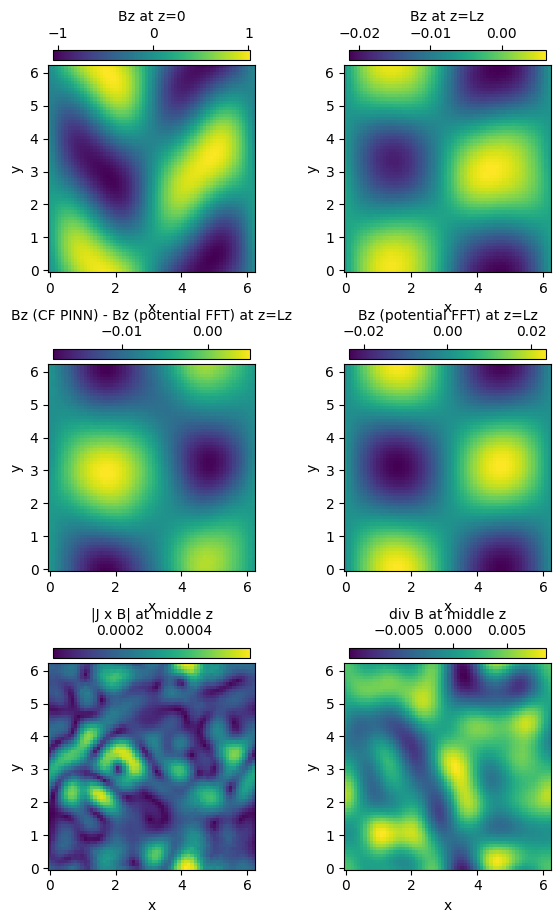

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import botf
import potf_pinns


class PeriodicBNet(nn.Module):
    """
    B(x, y, z) for horizontally periodic magnetic field.

    The network directly outputs Bx, By, Bz.
    x and y are encoded using sin/cos to enforce horizontal periodicity.
    """

    def __init__(
        self,
        lx: float,
        ly: float,
        lz: float,
        width: int = 128,
        depth: int = 5,
    ):
        super().__init__()
        self.lx = lx
        self.ly = ly
        self.lz = lz

        in_dim = 5  # sin x, cos x, sin y, cos y, z
        layers = []
        layers.append(nn.Linear(in_dim, width))
        layers.append(nn.Tanh())
        for _ in range(depth - 1):
            layers.append(nn.Linear(width, width))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(width, 3))  # Bx, By, Bz
        self.net = nn.Sequential(*layers)

    def forward(self, x, y, z):
        # 周期境界に対応するため、座標を三角関数で入力
        xx = 2.0 * torch.pi * x / self.lx
        yy = 2.0 * torch.pi * y / self.ly

        # zは[-1, 1]に正規化して入力
        zz = 2.0 * z / self.lz - 1.0

        inp = torch.cat(
            [torch.sin(xx), torch.cos(xx), torch.sin(yy), torch.cos(yy), zz],
            dim=-1,
        )
        return self.net(inp)


def grad(u, x):
    return torch.autograd.grad(
        u,
        x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True,
    )[0]


def curl_and_div(B, x, y, z):
    """Return J=curl(B) and div(B). mu0 is omitted."""
    bx = B[:, 0:1]
    by = B[:, 1:2]
    bz = B[:, 2:3]

    bx_x = grad(bx, x)
    bx_y = grad(bx, y)
    bx_z = grad(bx, z)

    by_x = grad(by, x)
    by_y = grad(by, y)
    by_z = grad(by, z)

    bz_x = grad(bz, x)
    bz_y = grad(bz, y)
    bz_z = grad(bz, z)

    jx = bz_y - by_z
    jy = bx_z - bz_x
    jz = by_x - bx_y

    div_b = bx_x + by_y + bz_z

    J = torch.cat([jx, jy, jz], dim=-1)
    return J, div_b


def current_free_losses(model, x, y, z, eps=1.0e-8):
    B = model(x, y, z)
    J, div_b = curl_and_div(B, x, y, z)

    # |J|^2
    loss_current = torch.mean(torch.sum(J**2, dim=-1, keepdim=True))

    # |div B|^2
    loss_div = torch.mean(div_b**2)

    return loss_current, loss_div


def sample_periodic_b0(b0_grid, x, y, lx, ly):
    """
    Bilinear sampling from Bz bottom grid.

    b0_grid: tensor with shape (ny, nx)
    x, y: tensors with shape (n, 1), physical coordinates
    """

    ny, nx = b0_grid.shape

    # Periodic wrap
    xw = torch.remainder(x, lx)
    yw = torch.remainder(y, ly)

    # Convert to grid indices
    gx = xw / lx * nx
    gy = yw / ly * ny

    i0 = torch.floor(gx).long() % nx
    j0 = torch.floor(gy).long() % ny
    i1 = (i0 + 1) % nx
    j1 = (j0 + 1) % ny

    tx = gx - torch.floor(gx)
    ty = gy - torch.floor(gy)

    b00 = b0_grid[j0.squeeze(-1), i0.squeeze(-1)].unsqueeze(-1)
    b10 = b0_grid[j0.squeeze(-1), i1.squeeze(-1)].unsqueeze(-1)
    b01 = b0_grid[j1.squeeze(-1), i0.squeeze(-1)].unsqueeze(-1)
    b11 = b0_grid[j1.squeeze(-1), i1.squeeze(-1)].unsqueeze(-1)

    return (
        (1.0 - tx) * (1.0 - ty) * b00
        + tx * (1.0 - ty) * b10
        + (1.0 - tx) * ty * b01
        + tx * ty * b11
    )


def make_points(n, lx, ly, lz, device):
    x = lx * torch.rand(n, 1, device=device, requires_grad=True)
    y = ly * torch.rand(n, 1, device=device, requires_grad=True)
    z = lz * torch.rand(n, 1, device=device, requires_grad=True)
    return x, y, z


def make_points_near_top(n, lx, ly, lz, device, thickness=0.2):
    x = lx * torch.rand(n, 1, device=device, requires_grad=True)
    y = ly * torch.rand(n, 1, device=device, requires_grad=True)

    # z in [(1-thickness)*lz, lz]
    z = lz * (1.0 - thickness * torch.rand(n, 1, device=device))
    z.requires_grad_(True)

    return x, y, z


def train(
    b0_grid,
    lx,
    ly,
    lz,
    steps=20000,
    n_pde=4096,
    n_bc=2048,
    lr=1.0e-3,
    T_max=3000,
    eta_min=1e-5,
    device="cuda",
):
    b0_grid = torch.as_tensor(b0_grid, dtype=torch.float32, device=device)

    model = PeriodicBNet(lx=lx, ly=ly, lz=lz).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt,
        T_max=T_max,
        eta_min=eta_min,
    )

    for step in range(steps):
        opt.zero_grad()

        # ---- Interior current-free and divB losses ----
        x, y, z = make_points(n_pde, lx, ly, lz, device)
        loss_current, loss_div = current_free_losses(model, x, y, z)

        # 上端付近の内部点を少し増やす
        xti, yti, zti = make_points_near_top(n_pde // 2, lx, ly, lz, device)
        loss_current_top_i, loss_div_top_i = current_free_losses(
            model, xti, yti, zti
        )

        loss_current = loss_current + loss_current_top_i
        loss_div = loss_div + loss_div_top_i

        # ---- Bottom boundary: Bz = B0 ----
        xb = lx * torch.rand(n_bc, 1, device=device, requires_grad=True)
        yb = ly * torch.rand(n_bc, 1, device=device, requires_grad=True)
        zb = torch.zeros(n_bc, 1, device=device, requires_grad=True)

        B_bottom_pred = model(xb, yb, zb)
        bz_bottom_pred = B_bottom_pred[:, 2:3]

        bz_bottom_target = sample_periodic_b0(b0_grid, xb, yb, lx, ly)
        loss_bottom_bz = torch.mean((bz_bottom_pred - bz_bottom_target) ** 2)

        # ---- Top boundary regularization ----
        xt = lx * torch.rand(n_bc, 1, device=device, requires_grad=True)
        yt = ly * torch.rand(n_bc, 1, device=device, requires_grad=True)
        zt = lz * torch.ones(n_bc, 1, device=device, requires_grad=True)

        B_top = model(xt, yt, zt)
        bx_top = B_top[:, 0:1]
        by_top = B_top[:, 1:2]

        # 上端では水平磁場を弱く消す
        loss_top_horizontal = torch.mean(bx_top**2 + by_top**2)

        # ---- Total loss ----
        loss = (
            1.0 * loss_current
            + 1.0 * loss_div
            + 10.0 * loss_bottom_bz
            + 0.1 * loss_top_horizontal
        )

        loss.backward()
        opt.step()
        scheduler.step()
        if step % 500 == 0:
            print(
                step,
                {
                    "loss": float(loss.detach().cpu()),
                    "current": float(loss_current.detach().cpu()),
                    "divB": float(loss_div.detach().cpu()),
                    "bottom_bz": float(loss_bottom_bz.detach().cpu()),
                    "top_h": float(loss_top_horizontal.detach().cpu()),
                },
            )

    return model


@torch.no_grad()
def evaluate_field(model, x1d, y1d, z1d, device="cuda"):
    """
    Returns Bx, By, Bz on meshgrid with shape (nz, ny, nx).
    """
    X, Y, Z = torch.meshgrid(
        torch.as_tensor(x1d, dtype=torch.float32, device=device),
        torch.as_tensor(y1d, dtype=torch.float32, device=device),
        torch.as_tensor(z1d, dtype=torch.float32, device=device),
        indexing="xy",
    )

    x = X.reshape(-1, 1)
    y = Y.reshape(-1, 1)
    z = Z.reshape(-1, 1)

    B = model(x, y, z)

    nx = len(x1d)
    ny = len(y1d)
    nz = len(z1d)

    bx = B[:, 0].reshape(ny, nx, nz).permute(2, 0, 1).detach().cpu()
    by = B[:, 1].reshape(ny, nx, nz).permute(2, 0, 1).detach().cpu()
    bz = B[:, 2].reshape(ny, nx, nz).permute(2, 0, 1).detach().cpu()

    return bx, by, bz


def evaluate_residuals(model, x1d, y1d, z1d, device="cuda"):
    """
    Evaluate |J x B| and divB on a grid.
    """
    X, Y, Z = torch.meshgrid(
        torch.as_tensor(x1d, dtype=torch.float32, device=device),
        torch.as_tensor(y1d, dtype=torch.float32, device=device),
        torch.as_tensor(z1d, dtype=torch.float32, device=device),
        indexing="xy",
    )

    x = X.reshape(-1, 1).detach().requires_grad_(True)
    y = Y.reshape(-1, 1).detach().requires_grad_(True)
    z = Z.reshape(-1, 1).detach().requires_grad_(True)

    B = model(x, y, z)
    J, div_b = curl_and_div(B, x, y, z)
    j_cross_b = torch.cross(J, B, dim=-1)

    nx = len(x1d)
    ny = len(y1d)
    nz = len(z1d)

    jxb_abs = torch.sqrt(torch.sum(j_cross_b**2, dim=-1))
    div_b = div_b[:, 0]

    jxb_abs = jxb_abs.reshape(ny, nx, nz).permute(2, 0, 1).detach().cpu()
    div_b = div_b.reshape(ny, nx, nz).permute(2, 0, 1).detach().cpu()

    return jxb_abs, div_b


def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("device:", device)

    # domain
    lx, ly, x, y, b0 = botf.make_multimode_bottom_bz()

    # size of vertical domain
    lz = 0.5 * lx

    # train
    model = train(
        b0_grid=b0,
        lx=lx,
        ly=ly,
        lz=lz,
        steps=10000,
        n_pde=4096,
        n_bc=1024,
        lr=1.0e-3,
        T_max=3000,
        eta_min=1e-5,
        device=device,
    )

    # evaluate field
    z = np.linspace(0.0, lz, len(x))

    _, _, bz = evaluate_field(model, x, y, z, device=device)

    # potential-field reference from FFT
    _, _, _, bz_ref = potf_pinns.solve_potential_field_fft_cartesian_at_z(
        b0_grid=b0,
        lx=lx,
        ly=ly,
        lz=lz,
        z=z,
    )

    # residuals
    jxb_abs, div_b = evaluate_residuals(model, x, y, z, device=device)

    # ---- plot data ----
    fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(7, 11))

    # plot bottom Bz
    ax = axs[0, 0]
    im = ax.pcolormesh(x, y, bz[0].numpy(), shading="auto")
    cb = fig.colorbar(im, location="top", pad=0.02, shrink=0.8)
    cb.set_label("Bz at z=0")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.label_outer()

    # plot top Bz
    ax = axs[0, 1]
    im = ax.pcolormesh(x, y, bz[-1].numpy(), shading="auto")
    cb = fig.colorbar(im, location="top", pad=0.02, shrink=0.8)
    cb.set_label("Bz at z=Lz")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.label_outer()

    # plot top Bz - potential reference
    ax = axs[1, 0]
    im = ax.pcolormesh(x, y, (bz[-1] - bz_ref[-1]).numpy(), shading="auto")
    cb = fig.colorbar(im, location="top", pad=0.02, shrink=0.8)
    cb.set_label("Bz (CF PINN) - Bz (potential FFT) at z=Lz")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.label_outer()

    # plot potential reference top Bz
    ax = axs[1, 1]
    im = ax.pcolormesh(x, y, bz_ref[-1], shading="auto")
    cb = fig.colorbar(im, location="top", pad=0.02, shrink=0.8)
    cb.set_label("Bz (potential FFT) at z=Lz")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.label_outer()

    # plot |J x B| at middle height
    iz = len(z) // 2
    ax = axs[2, 0]
    im = ax.pcolormesh(x, y, jxb_abs[iz].numpy(), shading="auto")
    cb = fig.colorbar(im, location="top", pad=0.02, shrink=0.8)
    cb.set_label("|J x B| at middle z")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.label_outer()

    # plot div B at middle height
    ax = axs[2, 1]
    im = ax.pcolormesh(x, y, div_b[iz].numpy(), shading="auto")
    cb = fig.colorbar(im, location="top", pad=0.02, shrink=0.8)
    cb.set_label("div B at middle z")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.label_outer()

    fig_file = "cff_pinns.png"
    plt.savefig(fig_file, dpi=150)
    print(f"Saved: {fig_file}")

    # save model
    pt_file = "cff_pinns.pt"
    torch.save(model.state_dict(), pt_file)
    print(f"Saved: {pt_file}")


if __name__ == "__main__":
    main()
